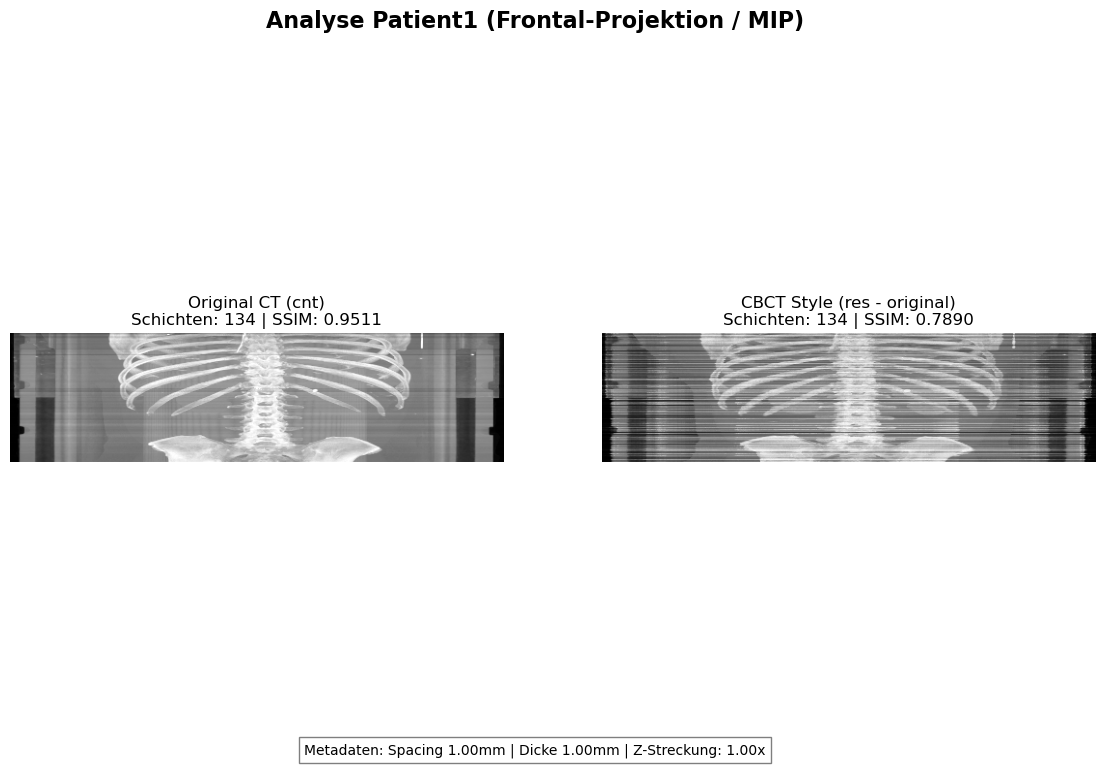

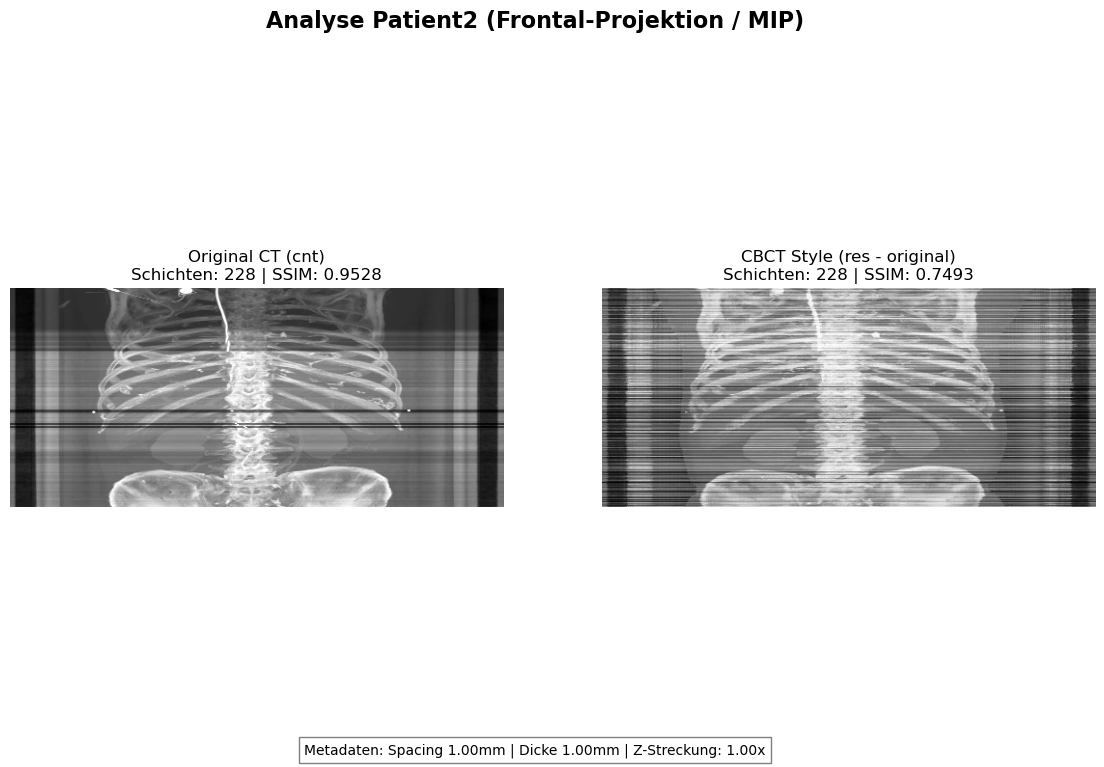

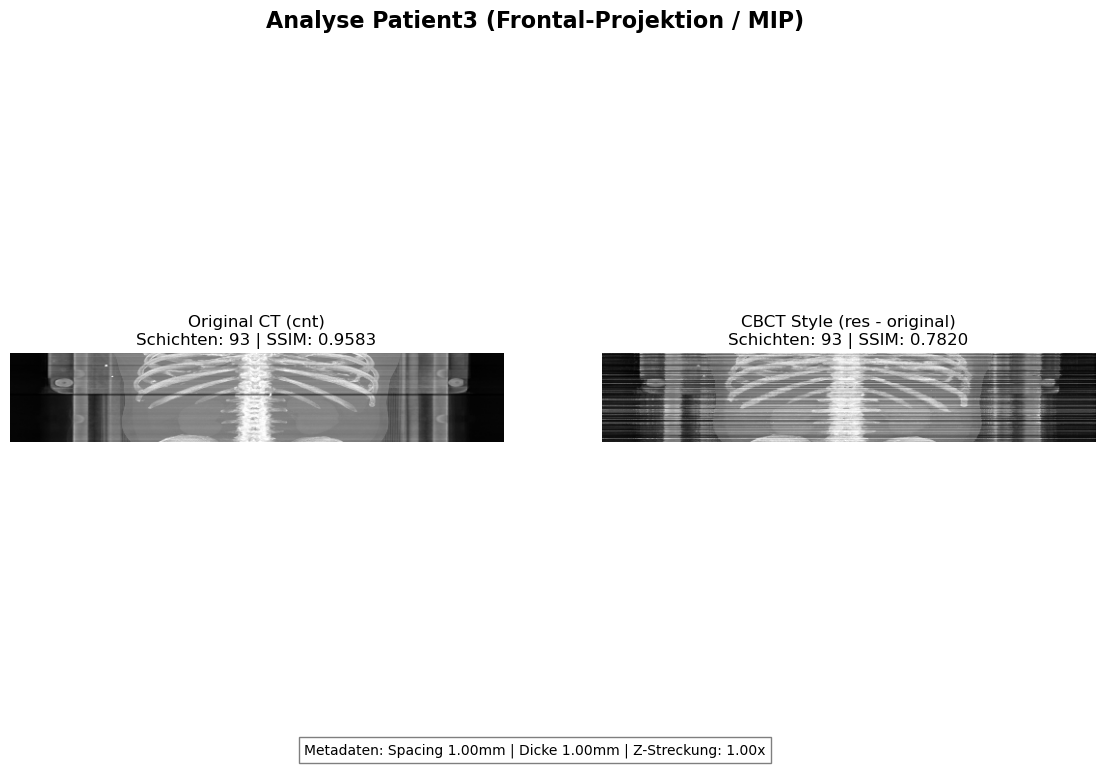

In [12]:
import pathlib
import pydicom
import cv2
import numpy as np
import re
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# --- HILFSFUNKTIONEN ---

def numerical_sort_key(path):
    numbers = re.findall(r'\d+', path.name)
    return int(numbers[-1]) if numbers else 0

def load_volume(folder_path):
    """Lädt alle Bilder eines Ordners (.dcm oder .png) zu einem 3D-Volumen."""
    files = sorted([f for f in folder_path.glob("*") if f.suffix.lower() in ['.dcm', '.png']], key=numerical_sort_key)
    if not files: return None, None, None
    
    volume = []
    spacing, thickness = [1.0, 1.0], 1.0
    
    for i, f in enumerate(files):
        if f.suffix.lower() == '.dcm':
            ds = pydicom.dcmread(str(f))
            if i == 0:
                spacing = ds.PixelSpacing if 'PixelSpacing' in ds else [1.0, 1.0]
                thickness = ds.SliceThickness if 'SliceThickness' in ds else 1.0
            img = ds.pixel_array.astype(float)
            img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-5) * 255
            volume.append(img.astype(np.uint8))
        else:
            volume.append(cv2.imread(str(f), cv2.IMREAD_GRAYSCALE))
            
    return np.array(volume), spacing, thickness

def get_projection_and_score(volume, z_factor):
    """Erstellt eine Frontal-Projektion (MIP) und berechnet den SSIM-Score."""
    if volume is None or len(volume) < 2: return None, 0.0
    
    # 1. Metrik: Inter-slice SSIM
    scores = [ssim(volume[i], volume[i+1], data_range=255) for i in range(len(volume)-1)]
    mean_score = np.mean(scores)
    
    # 2. Optik: Maximum Intensity Projection (von vorne nach hinten durchschauen)
    # Wir nehmen das Maximum entlang der Y-Achse
    mip = np.max(volume, axis=1)
    
    # Anatomisch korrekte Skalierung (Z-Achse strecken)
    new_h = int(mip.shape[0] * z_factor)
    mip_resized = cv2.resize(mip, (mip.shape[1], new_h), interpolation=cv2.INTER_CUBIC)
    
    return mip_resized, mean_score

# --- ANALYSE-LOOP FÜR PATIENTEN 1, 2, 3 ---

HAUPT_ORDNER = "Patienten" # Pfad zu deinem Hauptverzeichnis anpassen

for p_num in [1, 2, 3]:
    p_id = f"Patient{p_num}"
    p_path = pathlib.Path(HAUPT_ORDNER) / p_id
    
    if not p_path.exists():
        print(f"Überspringe {p_id}: Ordner existiert nicht.")
        continue

    # Volumina laden
    vol_cnt, spacing, thick = load_volume(p_path / f"{p_id}_cnt")
    vol_res, _, _ = load_volume(p_path / f"{p_id}_res")
    
    if vol_cnt is None or vol_res is None:
        print(f"Fehler bei {p_id}: Daten unvollständig.")
        continue
        
    z_factor = thick / spacing[0]
    
    # Projektionen und Metriken
    mip_cnt, score_cnt = get_projection_and_score(vol_cnt, z_factor)
    mip_res, score_res = get_projection_and_score(vol_res, z_factor)
    
    # Visualisierung
    # --- VISUALISIERUNG ANPASSEN ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    fig.suptitle(f"Analyse {p_id} (Frontal-Projektion / MIP)", fontsize=16, fontweight='bold')

    # Linkes Bild: CT mit Schichtenanzahl
    axes[0].imshow(mip_cnt, cmap='gray')
    axes[0].set_title(f"Original CT (cnt)\nSchichten: {len(vol_cnt)} | SSIM: {score_cnt:.4f}")
    axes[0].axis('off')

    # Rechtes Bild: CBCT mit Schichtenanzahl
    axes[1].imshow(mip_res, cmap='gray')
    axes[1].set_title(f"CBCT Style (res - original)\nSchichten: {len(vol_res)} | SSIM: {score_res:.4f}")
    axes[1].axis('off')

    info_box = f"Metadaten: Spacing {spacing[0]:.2f}mm | Dicke {thick:.2f}mm | Z-Streckung: {z_factor:.2f}x"
    plt.figtext(0.5, 0.05, info_box, ha="center", bbox={"facecolor":"white", "alpha":0.5})
    plt.show()